In [1]:
import numpy as np
import os
import pandas as pd
from pathlib import Path

from astropy.io import fits
from astropy.table import Table
from astropy.table import join
from astropy.table import vstack
from astropy.table import Column
import fitsio

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')
cmap = sns.color_palette('mako', as_cmap=True)

In [13]:
base = Path('/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior')

In [14]:
cosmos = ['c000', 'c102', 'c103', 'c112', 'c113', 'c104', 'c101', 'c100', 'c105']
phase = 'ph000'
seed = 'seed0'

In [15]:
hod_sets = {}

for c in cosmos:
    path = base / f'{c}_{phase}' / seed
    hods = sorted(p.stem for p in path.glob('hod*.fits'))
    hod_sets[c] = set(hods)
    print(f'{c}: {len(hods)} HOD files')

common_hods = sorted(set.intersection(*hod_sets.values()))

print('\ncommon')
print(f'Total: {len(common_hods)}')
print(common_hods)

c000: 500 HOD files
c102: 500 HOD files
c103: 500 HOD files
c112: 500 HOD files
c113: 500 HOD files
c104: 500 HOD files
c101: 500 HOD files
c100: 500 HOD files
c105: 500 HOD files

common
Total: 5
['hod091', 'hod097', 'hod216', 'hod297', 'hod584']


In [33]:
p0 = '/pscratch/sd/v/vtorresg/fisher_info/pypower_pk/pk_pypower_HOD_c000_ph000_seed0_hod000_N256.csv'
p1 = '/pscratch/sd/v/vtorresg/fisher_info/pypower_pk/pk_pypower_HOD_c101_ph000_seed0_hod000_N256.csv'
p2 = '/pscratch/sd/v/vtorresg/fisher_info/pypower_pk/pk_pypower_HOD_c102_ph000_seed0_hod000_N256.csv'
p4 = '/pscratch/sd/v/vtorresg/fisher_info/pypower_pk/pk_pypower_HOD_c104_ph000_seed0_hod000_N256.csv'

In [34]:
df_c000 = pd.read_csv(p0)
df_c101 = pd.read_csv(p1)
df_c102 = pd.read_csv(p2)
# df_c104 = pd.read_csv(p4)

In [35]:
envs = ['pvoid', 'psheet', 'pfilament', 'pknot']

In [36]:
k = df_c000['k_h_mpc'].values
kmask = (k >= 0.05) & (k <= 0.20)

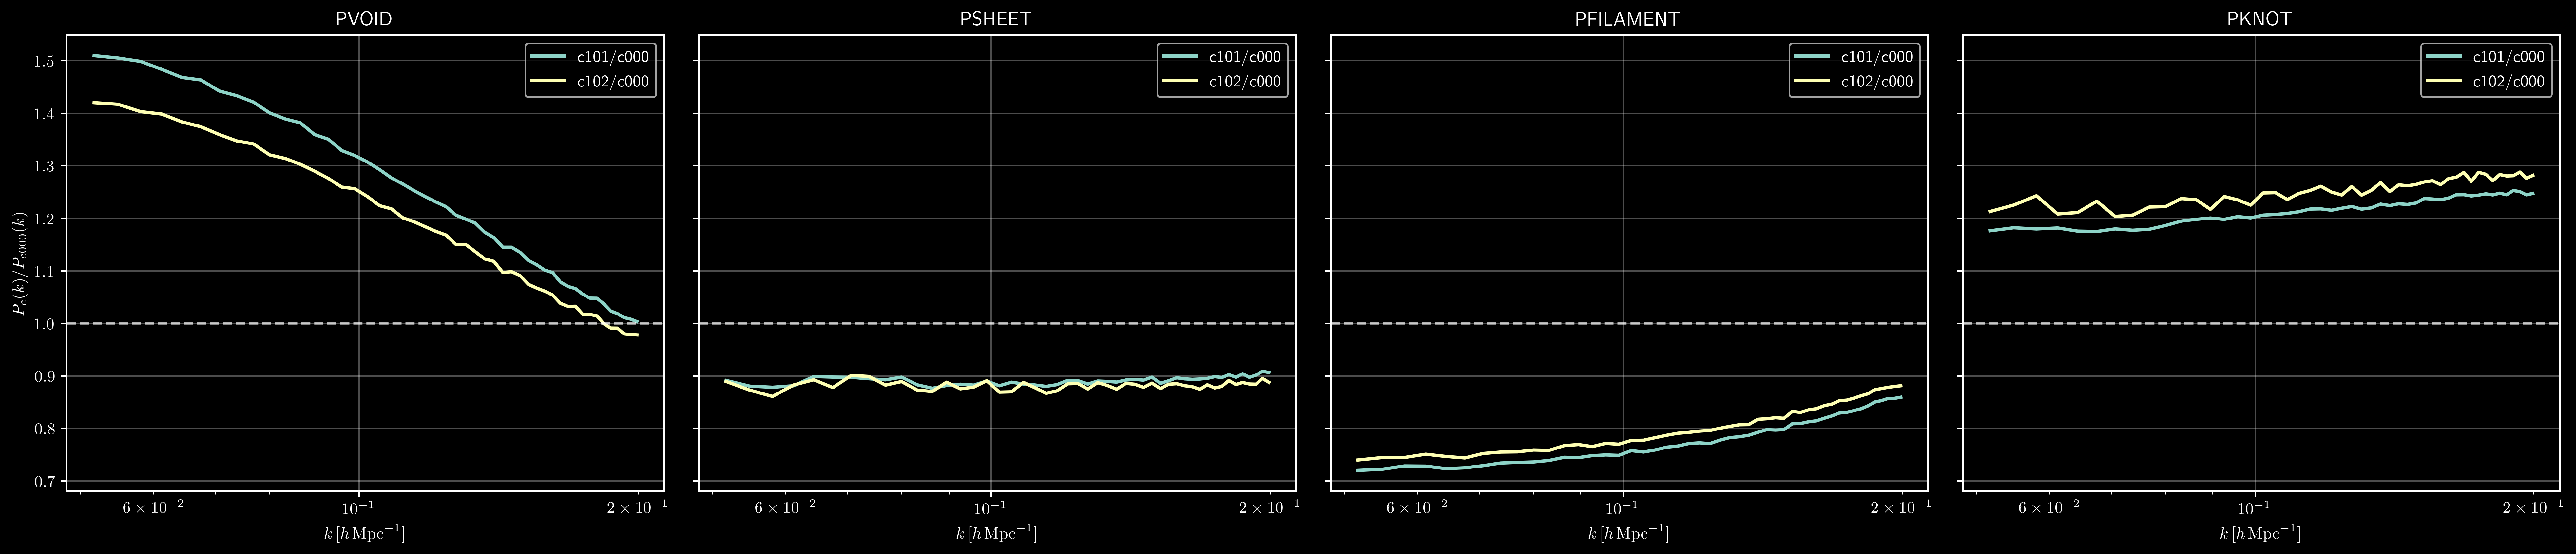

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.8), sharex=True, sharey=True)

for ax, env in zip(axes, envs):
    col = f'pk_marked_over_unmarked_{env}'

    O0 = df_c000[col].values
    O1 = df_c101[col].values
    O2 = df_c102[col].values
    # O4 = df_c104[col].values

    ax.plot(k[kmask], (O1 / O0)[kmask], lw=2, label='c101/c000')
    ax.plot(k[kmask], (O2 / O0)[kmask], lw=2, label='c102/c000')
    # ax.plot(k[kmask], (O4 / O0)[kmask], lw=2, label='c104/c000')

    ax.axhline(1.0, ls='--', color='white', alpha=0.7)
    ax.set_xscale('log')
    ax.set_title(env.upper())
    ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel(r'$P_c(k)/P_{c000}(k)$')

plt.tight_layout()
plt.show()